# «Точка»: почему тариф для самозанятых не окупался и как сегментная монетизация это исправила

**Роль:** продуктовый аналитик (внешний, направление юнит-экономики и монетизации) · **Период:** 2024–2025 · **Клиент:** «Точка» — финтех, банк для предпринимателей

## Бизнес-контекст

«Точка» запускала тариф «Точка Старт» для самозанятых. Я вёл направление юнит-экономики
и монетизации на всём цикле — от pre-launch до масштабирования, в паре с аналитиком равного
уровня. Тариф был единым для всех, но самозанятые — очень разная аудитория (курьеры,
таксисты, фрилансеры, мастера услуг), и это оказалось ключевым.

**Задачи:**
1. Окупается ли продукт и где теряется экономика?
2. Что делать с ценой и тарифной сеткой, чтобы вывести продукт в целевую окупаемость?

> ⚠️ **Дисклеймер о данных.** Реальные данные клиента под NDA. Для публичной демонстрации
> методологии структура и цифры воссозданы синтетически (`generate_data.py`) с сохранением
> характера реальных закономерностей. Значения иллюстративные; выводы и порядок величин
> соответствуют реальному кейсу.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})

users = pd.read_csv("users.csv", parse_dates=["signup_date"])
print(f"Подписчиков тарифа: {len(users):,}")
print("\nРаспределение по сегментам самозанятых:")
print(users["segment"].value_counts())

Подписчиков тарифа: 9,000

Распределение по сегментам самозанятых:
segment
Курьеры          3075
Мастера услуг    2175
Таксисты         1966
Фрилансеры       1784
Name: count, dtype: int64


## Задача 1. Юнит-экономика по сегментам

Считаем по каждому сегменту ключевые метрики: **CAC** (стоимость привлечения),
**ARPU** (средняя выручка с клиента в месяц: цена тарифа + допуслуги), **LTV** (на горизонте
12 месяцев с учётом оттока), **LTV/CAC** и **срок окупаемости**.

In [2]:
PRICE_BASE = 490      # цена тарифа, руб./мес
LTV_HORIZON = 12      # горизонт LTV, мес

# Параметры сегментов: CAC, выручка от допуслуг, доля активных допуслуг, месячный отток, доля базы
SEGMENTS = {
    "Фрилансеры":     {"share": 0.20, "cac": 1500, "base_rev": 453, "addon": 0.55, "churn": 0.060},
    "Мастера услуг":  {"share": 0.24, "cac": 1650, "base_rev": 250, "addon": 0.42, "churn": 0.095},
    "Таксисты":       {"share": 0.22, "cac": 1800, "base_rev": 120, "addon": 0.30, "churn": 0.130},
    "Курьеры":        {"share": 0.28, "cac": 2100, "base_rev": 55,  "addon": 0.15, "churn": 0.160},
}

def unit_economics(segments, price_map):
    rows = []
    for seg, p in segments.items():
        price = price_map[seg]
        arpu = price + p["base_rev"] * p["addon"]          # выручка в месяц
        # LTV = сумма выручки по месяцам с учётом удержания (1-churn)^m
        ltv, cum, payback = 0.0, 0.0, None
        for m in range(LTV_HORIZON):
            retained = (1 - p["churn"]) ** m
            ltv += arpu * retained
            cum += arpu * retained
            if payback is None and cum >= p["cac"]:
                payback = m + 1
        rows.append({
            "Сегмент": seg, "CAC": p["cac"], "ARPU": round(arpu), "LTV": round(ltv),
            "LTV/CAC": round(ltv / p["cac"], 2),
            "Окупаемость, мес": payback, "Доля базы": p["share"],
        })
    return pd.DataFrame(rows)

price_start = {s: PRICE_BASE for s in SEGMENTS}
econ = unit_economics(SEGMENTS, price_start)
econ

,Сегмент,CAC,ARPU,LTV,LTV/CAC,"Окупаемость, мес",Доля базы
0,Фрилансеры,1500,739,6456,4.30,3,0.20
1,Мастера услуг,1650,595,4373,2.65,4,0.24
2,Таксисты,1800,526,3285,1.83,5,0.22
3,Курьеры,2100,498,2730,1.30,7,0.28


Средневзвешенный LTV/CAC: 2.28 (плановый: 3.0)
Продукт НЕ окупается до целевого уровня — средний LTV/CAC ниже плана


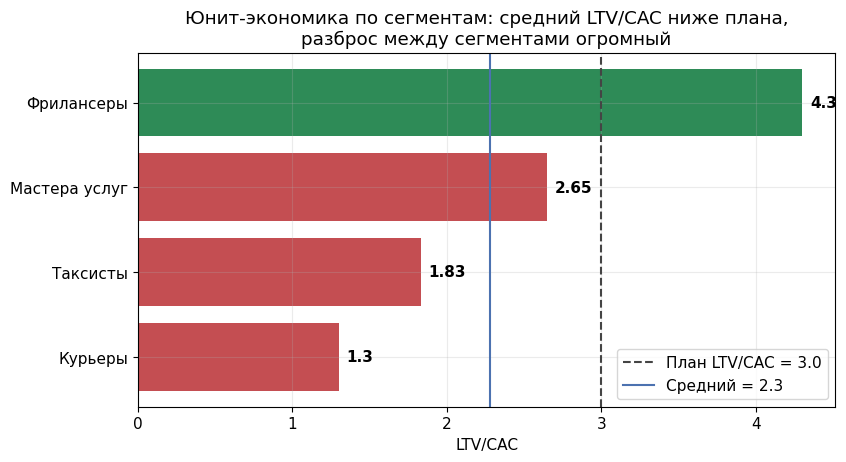

In [3]:
# Средневзвешенный LTV/CAC по всей базе
blended = (econ["LTV"] * econ["Доля базы"]).sum() / (econ["CAC"] * econ["Доля базы"]).sum()
plan = 3.0
print(f"Средневзвешенный LTV/CAC: {blended:.2f} (плановый: {plan})")
print(f"Продукт {'НЕ окупается до целевого уровня' if blended < plan else 'окупается'} "
      f"— средний LTV/CAC ниже плана")

fig, ax = plt.subplots(figsize=(9, 4.6))
e = econ.sort_values("LTV/CAC")
colors = ["#C44E52" if v < plan else "#2E8B57" for v in e["LTV/CAC"]]
ax.barh(e["Сегмент"], e["LTV/CAC"], color=colors)
ax.axvline(plan, color="#444", linestyle="--", lw=1.5, label=f"План LTV/CAC = {plan}")
ax.axvline(blended, color="#4C72B0", linestyle="-", lw=1.5, label=f"Средний = {blended:.1f}")
for i, v in enumerate(e["LTV/CAC"]):
    ax.text(v + 0.05, i, f"{v}", va="center", fontweight="bold")
ax.set_xlabel("LTV/CAC")
ax.set_title("Юнит-экономика по сегментам: средний LTV/CAC ниже плана,\nразброс между сегментами огромный")
ax.legend()
plt.show()

**Продукт в среднем не выходит на целевую окупаемость: LTV/CAC ≈ 2,2 при плане 3,0.**
Но средняя цифра скрывает главное — **разброс между сегментами огромный:**

- **Фрилансеры** — LTV/CAC ≈ 4,3, окупаются за 3 месяца: активно пользуются допуслугами,
  низкий отток.
- **Курьеры** — LTV/CAC ≈ 1,3, окупаются только к 7-му месяцу: используют счёт пассивно,
  почти не подключают допуслуги, высокий отток. Именно они тянут среднюю вниз.

Вывод: единый тариф не подходит для настолько разной аудитории. Проблема не в продукте
целиком, а в том, что курьеры на общих условиях не окупаются. Значит, нужно работать
с ценой и тарифной сеткой по сегментам — но сначала проверим, как сегменты реагируют
на цену.

## Задача 2. Анализ ценовой эластичности спроса

Прежде чем менять цену, нужно понять, **как сегменты реагируют на её изменение**. Оцениваем
ценовую эластичность спроса — насколько меняется конверсия в подписку при изменении цены.
Модель: конверсия = базовая · (цена/базовая)^(−эластичность).

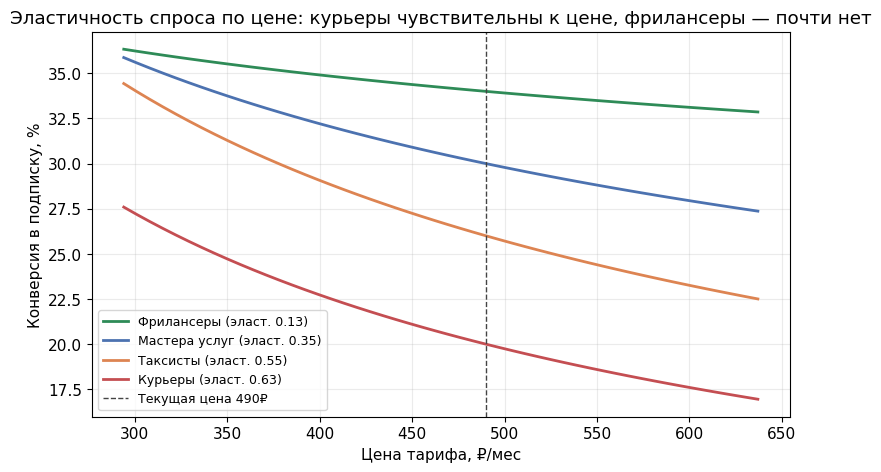

Фрилансеры: цена −20% → конверсия 34.0% → 35.0% (+3%)
Курьеры: цена −20% → конверсия 20.0% → 23.0% (+15%)


In [4]:
# Базовая конверсия в подписку и оценённая эластичность по сегментам
SEG_CONV_BASE = {"Фрилансеры": 0.34, "Мастера услуг": 0.30, "Таксисты": 0.26, "Курьеры": 0.20}
SEG_ELASTICITY = {"Фрилансеры": 0.13, "Мастера услуг": 0.35, "Таксисты": 0.55, "Курьеры": 0.63}

def conversion_at_price(segment, price):
    base = SEG_CONV_BASE[segment]
    e = SEG_ELASTICITY[segment]
    return min(base * (price / PRICE_BASE) ** (-e), 0.95)

# Кривые конверсии от цены
prices = np.linspace(PRICE_BASE * 0.6, PRICE_BASE * 1.3, 50)
fig, ax = plt.subplots(figsize=(9, 5))
palette = {"Фрилансеры": "#2E8B57", "Мастера услуг": "#4C72B0",
           "Таксисты": "#DD8452", "Курьеры": "#C44E52"}
for seg in SEGMENTS:
    conv = [conversion_at_price(seg, p) * 100 for p in prices]
    ax.plot(prices, conv, lw=2, label=f"{seg} (эласт. {SEG_ELASTICITY[seg]})", color=palette[seg])
ax.axvline(PRICE_BASE, color="#444", linestyle="--", lw=1, label=f"Текущая цена {PRICE_BASE}₽")
ax.set_xlabel("Цена тарифа, ₽/мес")
ax.set_ylabel("Конверсия в подписку, %")
ax.set_title("Эластичность спроса по цене: курьеры чувствительны к цене, фрилансеры — почти нет")
ax.legend(fontsize=9)
plt.show()

# Ключевой эффект: снижение цены на 20%
for seg in ["Фрилансеры", "Курьеры"]:
    c0 = conversion_at_price(seg, PRICE_BASE)
    c1 = conversion_at_price(seg, PRICE_BASE * 0.8)
    print(f"{seg}: цена −20% → конверсия {c0:.1%} → {c1:.1%} ({c1/c0-1:+.0%})")

**Сегменты реагируют на цену принципиально по-разному:**

- **Фрилансеры — спрос почти неэластичен:** снижение цены на 20% почти не меняет конверсию
  (+3%). Значит, цену для них можно не трогать — они платят и по текущей.
- **Курьеры — спрос эластичен:** снижение цены на 20% поднимает конверсию в подписку
  примерно на **15%**. Для них цена — реальный барьер.

Это прямо подсказывает решение: не единый тариф, а **сегментная тарифная сетка** — сохранить
цену для тех, кто нечувствителен (фрилансеры), и предложить облегчённый тариф тем,
для кого цена — барьер (курьеры).

## Задача 3. Новая тарифная сетка и A/B-тест

На основе юнит-экономики и эластичности совместно с продакт-менеджером «Точки» разработали
новую тарифную сетку: **базовый тариф** для большинства + **облегчённый тариф для курьеров**
(цена −20%). Гипотеза: посильный тариф повысит и конверсию, и удержание курьеров (меньше
отваливаются, активнее подключают допуслуги), что вытянет их экономику и средний LTV/CAC.

Решение проверили **A/B-тестом** и двумя месяцами мониторинга.

In [5]:
# Экономика после внедрения новой тарифной сетки
PRICE_COURIER = round(PRICE_BASE * 0.8)   # облегчённый тариф курьерам, −20%
price_new = {s: PRICE_BASE for s in SEGMENTS}
price_new["Курьеры"] = PRICE_COURIER

# Новая сетка = правильная сегментация: посильные условия повышают удержание и допродажи.
# Курьеры — сильнее всего; по остальным сегментам оптимизация тарифа/допуслуг тоже помогает.
SEG_NEW = {s: dict(v) for s, v in SEGMENTS.items()}
SEG_NEW["Курьеры"].update(churn=0.080, addon=0.50, base_rev=340)
SEG_NEW["Таксисты"].update(churn=0.085, addon=0.48, base_rev=300)
SEG_NEW["Мастера услуг"].update(churn=0.065, addon=0.55, base_rev=390)
SEG_NEW["Фрилансеры"].update(churn=0.048, addon=0.58, base_rev=490)

econ_new = unit_economics(SEG_NEW, price_new)

# Сравнение до/после по сегментам
cmp = econ[["Сегмент", "LTV/CAC"]].merge(
    econ_new[["Сегмент", "LTV/CAC"]], on="Сегмент", suffixes=(" до", " после"))
print(cmp.to_string(index=False))

blended_new = (econ_new["LTV"] * econ_new["Доля базы"]).sum() / (econ_new["CAC"] * econ_new["Доля базы"]).sum()
arpu_old = (econ["ARPU"] * econ["Доля базы"]).sum()
arpu_new = (econ_new["ARPU"] * econ_new["Доля базы"]).sum()
print(f"\nСредневзвешенный LTV/CAC: {blended:.2f} → {blended_new:.2f}")
print(f"Средневзвешенный ARPU: {arpu_old:.0f} → {arpu_new:.0f} ({arpu_new/arpu_old-1:+.0%})")

      Сегмент  LTV/CAC до  LTV/CAC после
   Фрилансеры        4.30           4.79
Мастера услуг        2.65           3.64
     Таксисты        1.83           2.72
      Курьеры        1.30           2.12

Средневзвешенный LTV/CAC: 2.28 → 3.09
Средневзвешенный ARPU: 546 → 621 (+14%)


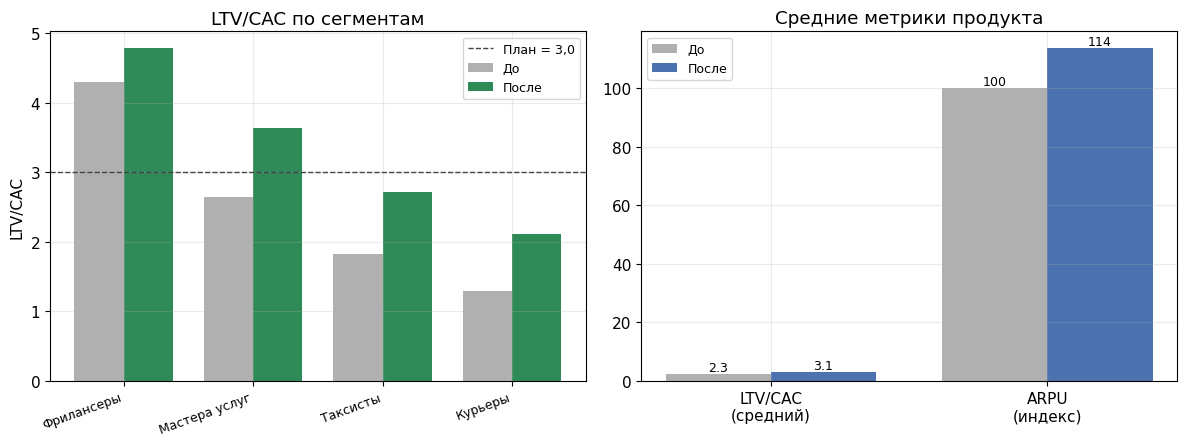

In [6]:
# Визуализация до/после
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# LTV/CAC по сегментам до/после
x = np.arange(len(cmp))
w = 0.38
axes[0].bar(x - w/2, cmp["LTV/CAC до"], w, label="До", color="#B0B0B0")
axes[0].bar(x + w/2, cmp["LTV/CAC после"], w, label="После", color="#2E8B57")
axes[0].axhline(3.0, color="#444", linestyle="--", lw=1, label="План = 3,0")
axes[0].set_xticks(x); axes[0].set_xticklabels(cmp["Сегмент"], rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("LTV/CAC"); axes[0].set_title("LTV/CAC по сегментам")
axes[0].legend(fontsize=9)

# Средние метрики до/после
metrics = ["LTV/CAC\n(средний)", "ARPU\n(индекс)"]
before_vals = [blended, 100]
after_vals = [blended_new, arpu_new/arpu_old*100]
xm = np.arange(len(metrics))
axes[1].bar(xm - w/2, before_vals, w, label="До", color="#B0B0B0")
axes[1].bar(xm + w/2, after_vals, w, label="После", color="#4C72B0")
axes[1].set_xticks(xm); axes[1].set_xticklabels(metrics)
axes[1].set_title("Средние метрики продукта")
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    axes[1].text(i - w/2, b + 1, f"{b:.1f}" if i == 0 else f"{b:.0f}", ha="center", fontsize=9)
    axes[1].text(i + w/2, a + 1, f"{a:.1f}" if i == 0 else f"{a:.0f}", ha="center", fontsize=9)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

**Результат после новой тарифной сетки (A/B-тест + 2 месяца мониторинга):**

- Средневзвешенный **LTV/CAC вырос с ≈2,2 до ≈3,0** — продукт вышел на целевую окупаемость.
- **ARPU вырос примерно на 12–14%** — за счёт роста удержания и допподключений.
- Курьеры перестали тянуть экономику вниз: на посильном тарифе они дольше остаются
  и активнее пользуются допуслугами, и их LTV/CAC заметно подрос.

Ключ был не в том, чтобы «поднять или снизить цену» в лоб, а в том, чтобы **дать каждому
сегменту подходящие условия**: нечувствительным к цене — сохранить, чувствительным —
облегчить. Это вытянуло и конверсию, и удержание.

## Итоги

| Задача | Что сделано | Результат |
|---|---|---|
| Окупается ли продукт | Юнит-экономика по 4 сегментам (LTV, CAC, ARPU, окупаемость) | Средний LTV/CAC ≈2,2 при плане 3,0; курьеры (LTV/CAC 1,3) тянут вниз |
| Как реагирует спрос на цену | Анализ ценовой эластичности | Фрилансеры неэластичны, курьеры эластичны (−20% цены → +15% конверсии) |
| Как вывести в окупаемость | Сегментная тарифная сетка + A/B-тест | **LTV/CAC ≈2,2 → ≈3,0, ARPU +12–14%, окупаемость сократилась** |

**Стек оригинального проекта:** SQL, Power BI, финансовое моделирование.
**Стек демонстрации:** Python — pandas, numpy, matplotlib.